<a href="https://colab.research.google.com/github/awaliyah11/project-ml/blob/main/Klasifikasi_Transaksi_Kartu_Kredit_Fraud_pada_Dataset_Transaksi_Keuangan.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Klasifikasi Transaksi Kartu Kredit Fraud pada Dataset Transaksi Keuangan

IMPOR LIBRARY

In [106]:
# =====================================
# IMPORT LIBRARY
# =====================================

!pip install imbalanced-learn

import pandas as pd
import numpy as np

import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, RandomizedSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from imblearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve, auc,
    precision_recall_curve
)

from imblearn.over_sampling import SMOTE

PEMAHAMAN DATA






*   Memuat Dataset




In [107]:
df = pd.read_csv("credit_card_fraud.csv")
df_original = df.copy()

print(df.shape)
print(df.head())

(10000, 10)
   transaction_id  amount  transaction_hour merchant_category  \
0               1   84.47                22       Electronics   
1               2  541.82                 3            Travel   
2               3  237.01                17           Grocery   
3               4  164.33                 4           Grocery   
4               5   30.53                15              Food   

   foreign_transaction  location_mismatch  device_trust_score  \
0                    0                  0                  66   
1                    1                  0                  87   
2                    0                  0                  49   
3                    0                  1                  72   
4                    0                  0                  79   

   velocity_last_24h  cardholder_age  is_fraud  
0                  3              40         0  
1                  1              64         0  
2                  1              61         0  
3         

In [108]:
print("===== INFO DATA =====")
df.info()

===== INFO DATA =====
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 10 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   transaction_id       10000 non-null  int64  
 1   amount               10000 non-null  float64
 2   transaction_hour     10000 non-null  int64  
 3   merchant_category    10000 non-null  object 
 4   foreign_transaction  10000 non-null  int64  
 5   location_mismatch    10000 non-null  int64  
 6   device_trust_score   10000 non-null  int64  
 7   velocity_last_24h    10000 non-null  int64  
 8   cardholder_age       10000 non-null  int64  
 9   is_fraud             10000 non-null  int64  
dtypes: float64(1), int64(8), object(1)
memory usage: 781.4+ KB


In [109]:
print("===== DESKRIPSI DATA =====")
df.describe()

===== DESKRIPSI DATA =====


,transaction_id,amount,transaction_hour,foreign_transaction,location_mismatch,device_trust_score,velocity_last_24h,cardholder_age,is_fraud
count,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,5000.50000,175.949849,11.593300,0.097800,0.085700,61.798900,2.008900,43.468700,0.015100
std,2886.89568,175.392827,6.922708,0.297059,0.279935,21.487053,1.432559,14.979147,0.121957
min,1.00000,0.000000,0.000000,0.000000,0.000000,25.000000,0.000000,18.000000,0.000000
25%,2500.75000,50.905000,6.000000,0.000000,0.000000,43.000000,1.000000,30.000000,0.000000
50%,5000.50000,122.095000,12.000000,0.000000,0.000000,62.000000,2.000000,44.000000,0.000000
75%,7500.25000,242.480000,18.000000,0.000000,0.000000,80.000000,3.000000,56.000000,0.000000
max,10000.00000,1471.040000,23.000000,1.000000,1.000000,99.000000,9.000000,69.000000,1.000000




*   Penjelasan Fitur Dataset




In [110]:
# =====================================
# PENJELASAN FITUR DATASET
# =====================================

features_info = {
"transaction_id":"ID unik setiap transaksi",
"amount":"Jumlah uang pada transaksi",
"transaction_hour":"Jam terjadinya transaksi",
"merchant_category":"Kategori merchant tempat transaksi",
"foreign_transaction":"Apakah transaksi dilakukan di luar negeri",
"location_mismatch":"Apakah lokasi transaksi berbeda dari lokasi normal pengguna",
"device_trust_score":"Skor kepercayaan perangkat yang digunakan",
"velocity_last_24h":"Jumlah transaksi dalam 24 jam terakhir",
"cardholder_age":"Usia pemegang kartu",
"is_fraud":"Label target (1 = fraud, 0 = normal)"
}

features_df = pd.DataFrame(
    features_info.items(),
    columns=["Fitur","Keterangan"]
)

features_df

,Fitur,Keterangan
0,transaction_id,ID unik setiap transaksi
1,amount,Jumlah uang pada transaksi
2,transaction_hour,Jam terjadinya transaksi
3,merchant_category,Kategori merchant tempat transaksi
4,foreign_transaction,Apakah transaksi dilakukan di luar negeri
5,location_mismatch,Apakah lokasi transaksi berbeda dari lokasi no...
6,device_trust_score,Skor kepercayaan perangkat yang digunakan
7,velocity_last_24h,Jumlah transaksi dalam 24 jam terakhir
8,cardholder_age,Usia pemegang kartu
9,is_fraud,"Label target (1 = fraud, 0 = normal)"


PRAPROSES DATA (DATA PREPROCESSING)



*   Pengecekan Missing Value




In [111]:
print("Missing value tiap kolom:")
print(df.isnull().sum())

Missing value tiap kolom:
transaction_id         0
amount                 0
transaction_hour       0
merchant_category      0
foreign_transaction    0
location_mismatch      0
device_trust_score     0
velocity_last_24h      0
cardholder_age         0
is_fraud               0
dtype: int64


In [112]:
df = df.dropna()



*   Penghapusan Kolom Tidak Diperlukan




In [113]:
#drop kolom
df = df.drop("transaction_id", axis=1)


*   Deteksi Outlier




In [114]:
#encoding kategori
df = pd.get_dummies(df, columns=["merchant_category"], drop_first=True)



*   Deteksi Outlier




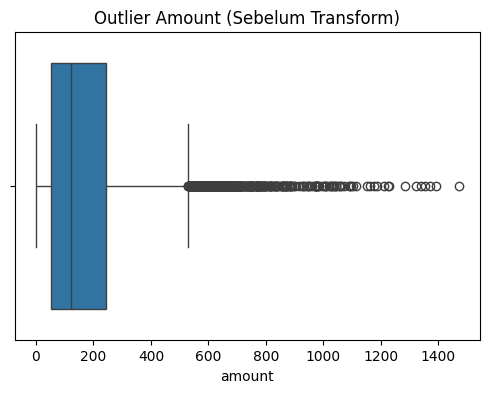

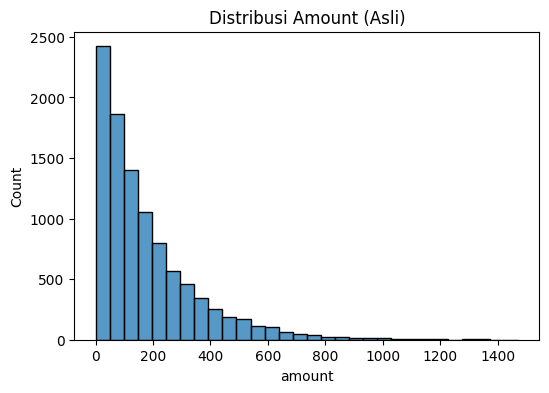

In [115]:
# =====================================
# DETEKSI OUTLIER PADA FITUR AMOUNT
# =====================================

plt.figure(figsize=(6,4))
sns.boxplot(x=df["amount"])
plt.title("Outlier Amount (Sebelum Transform)")
plt.show()

plt.figure(figsize=(6,4))
sns.histplot(df["amount"], bins=30)
plt.title("Distribusi Amount (Asli)")
plt.show()


In [116]:
df.columns

Index(['amount', 'transaction_hour', 'foreign_transaction',
       'location_mismatch', 'device_trust_score', 'velocity_last_24h',
       'cardholder_age', 'is_fraud', 'merchant_category_Electronics',
       'merchant_category_Food', 'merchant_category_Grocery',
       'merchant_category_Travel'],
      dtype='object')

In [117]:
print("JUMLAH FITUR:", X.shape[1])
print("DAFTAR FITUR:", list(X.columns))

JUMLAH FITUR: 11
DAFTAR FITUR: ['transaction_hour', 'foreign_transaction', 'location_mismatch', 'device_trust_score', 'velocity_last_24h', 'cardholder_age', 'merchant_category_Electronics', 'merchant_category_Food', 'merchant_category_Grocery', 'merchant_category_Travel', 'amount_log']


 ANALISIS DATA EKSPLORATIF (EDA)



*    Distribusi Target




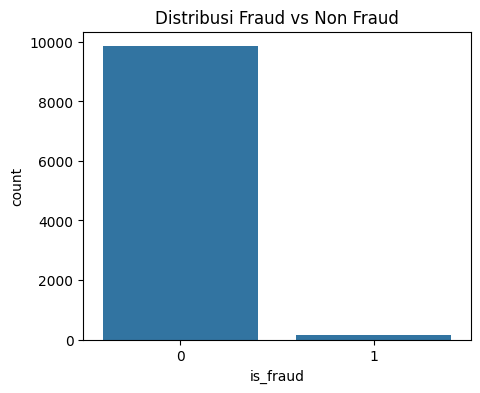


Distribusi Target (%):
is_fraud
0    0.9849
1    0.0151
Name: proportion, dtype: float64


In [118]:
plt.figure(figsize=(5,4))
sns.countplot(x='is_fraud', data=df)
plt.title("Distribusi Fraud vs Non Fraud")
plt.show()

print("\nDistribusi Target (%):")
print(df["is_fraud"].value_counts(normalize=True))



*   Korelasi Antar Variabel




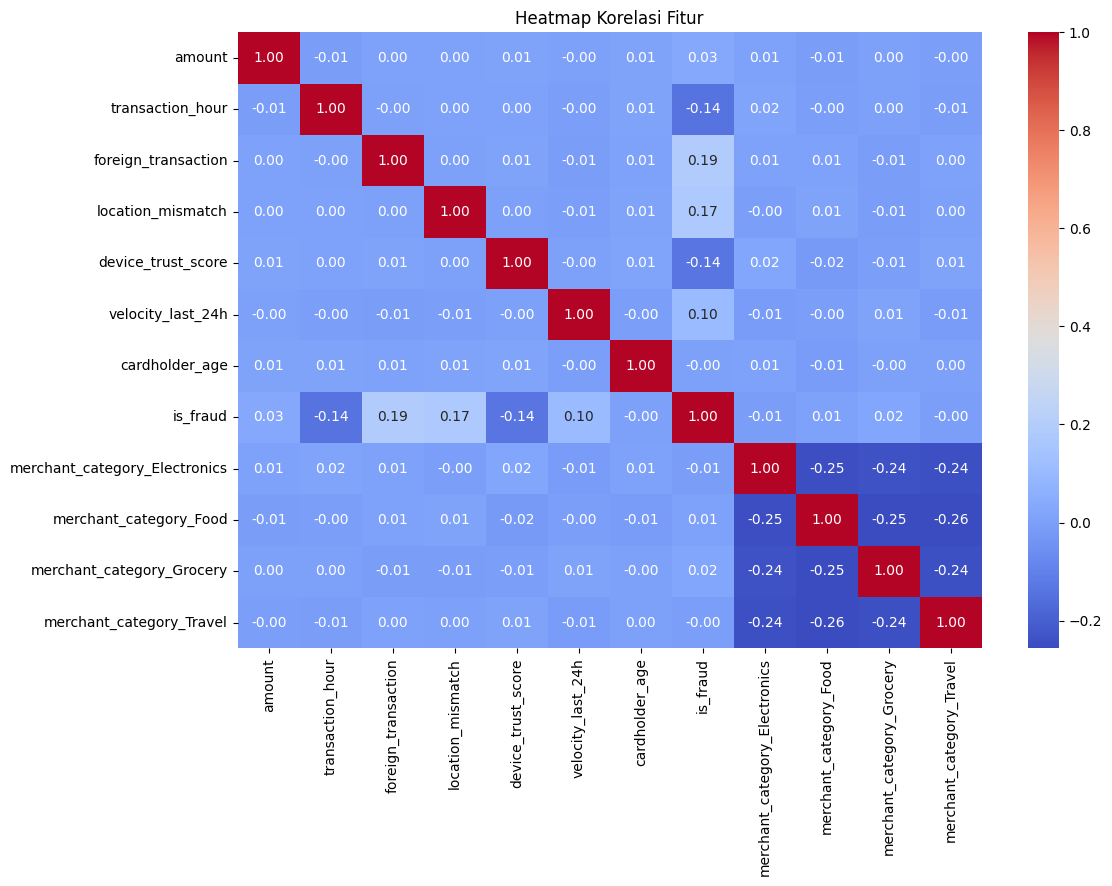

In [119]:
# =====================================
# KORELASI ANTAR FITUR
# =====================================

plt.figure(figsize=(12,8))
sns.heatmap(df.corr(), cmap="coolwarm", annot=True, fmt=".2f")
plt.title("Heatmap Korelasi Fitur")
plt.show()


*   Perbandingan Amount Fraud vs Non Fraud



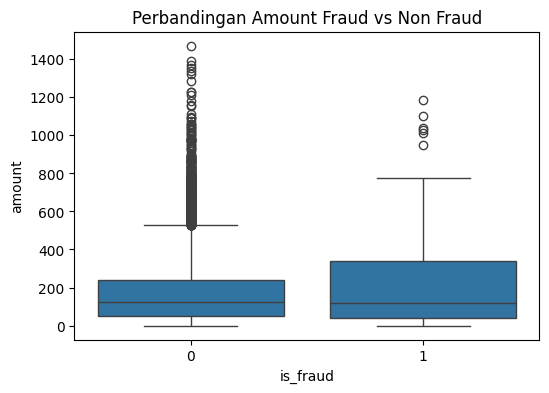

In [120]:
# =======================================
# Perbandingan Amount Fraud vs Non Fraud
# =======================================
plt.figure(figsize=(6,4))
sns.boxplot(x="is_fraud", y="amount", data=df)
plt.title("Perbandingan Amount Fraud vs Non Fraud")
plt.show()



*   Distribusi fraud berdasarkan jam transaksi



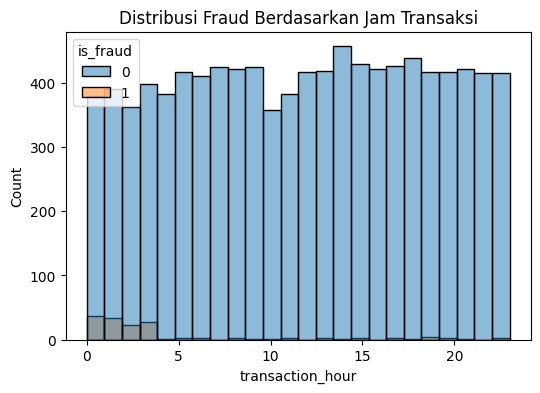

In [121]:
# ===========================================
# Distribusi fraud berdasarkan jam transaksi
# ===========================================
plt.figure(figsize=(6,4))
sns.histplot(data=df, x="transaction_hour", hue="is_fraud", bins=24)
plt.title("Distribusi Fraud Berdasarkan Jam Transaksi")
plt.show()

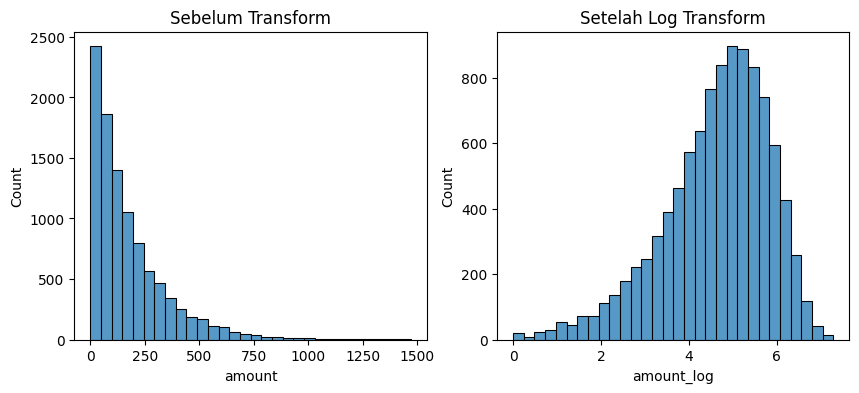


Fitur setelah preprocessing:
Index(['transaction_hour', 'foreign_transaction', 'location_mismatch',
       'device_trust_score', 'velocity_last_24h', 'cardholder_age', 'is_fraud',
       'merchant_category_Electronics', 'merchant_category_Food',
       'merchant_category_Grocery', 'merchant_category_Travel', 'amount_log'],
      dtype='object')


In [122]:
# =====================================
# LOG TRANSFORM
# =====================================
df["amount_log"] = np.log1p(df["amount"])


# =====================================
# VISUALISASI SETELAH TRANSFORM
# =====================================
plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
sns.histplot(df_original["amount"], bins=30)
plt.title("Sebelum Transform")

plt.subplot(1,2,2)
sns.histplot(df["amount_log"], bins=30)
plt.title("Setelah Log Transform")

plt.show()


# =====================================
# HAPUS KOLOM LAMA
# =====================================
df = df.drop("amount", axis=1)


# =====================================
# CEK HASIL AKHIR
# =====================================
print("\nFitur setelah preprocessing:")
print(df.columns)

In [123]:
#pisahkan fitur & target
X = df.drop("is_fraud", axis=1)
y = df["is_fraud"]

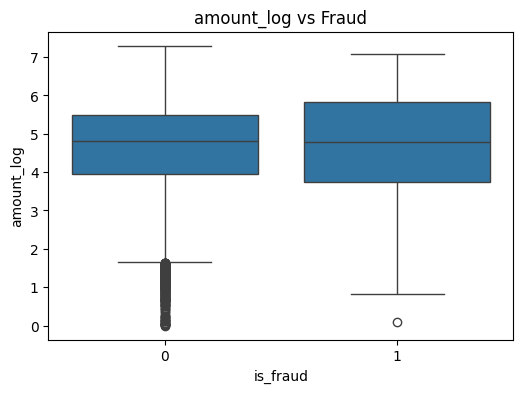

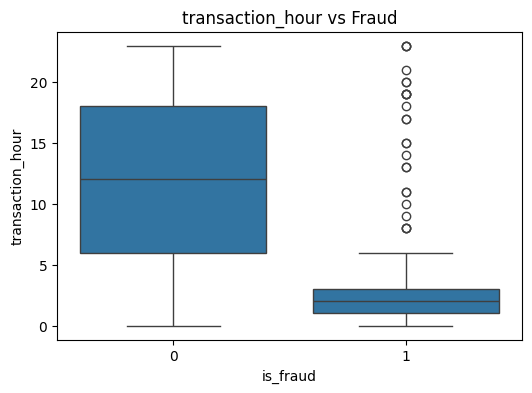

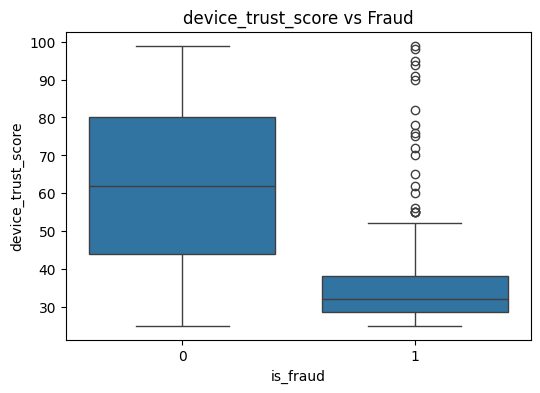

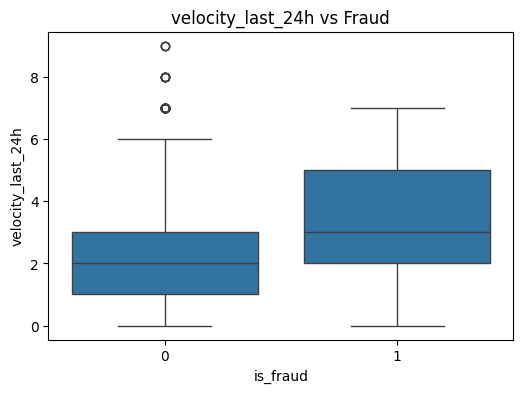

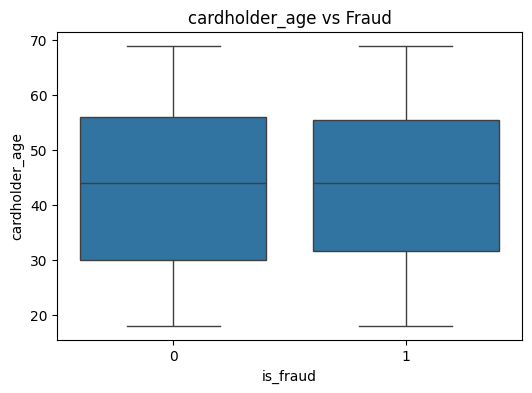

In [124]:
# =====================================
# HUBUNGAN FITUR NUMERIK vs TARGET
# =====================================

numerical_features = ["amount_log", "transaction_hour", "device_trust_score",
                      "velocity_last_24h", "cardholder_age"]

for col in numerical_features:
    plt.figure(figsize=(6,4))
    sns.boxplot(x="is_fraud", y=col, data=df)
    plt.title(f"{col} vs Fraud")
    plt.show()

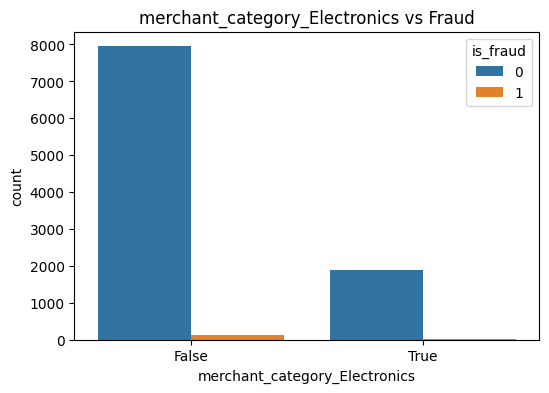

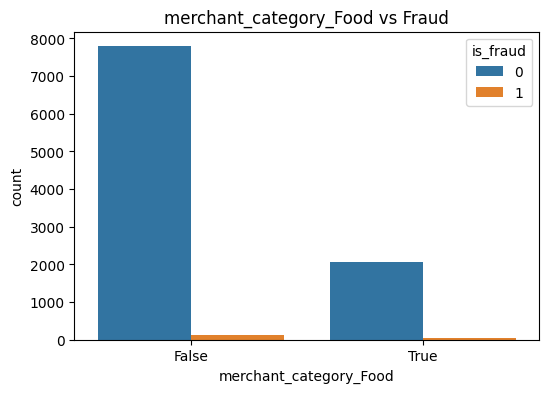

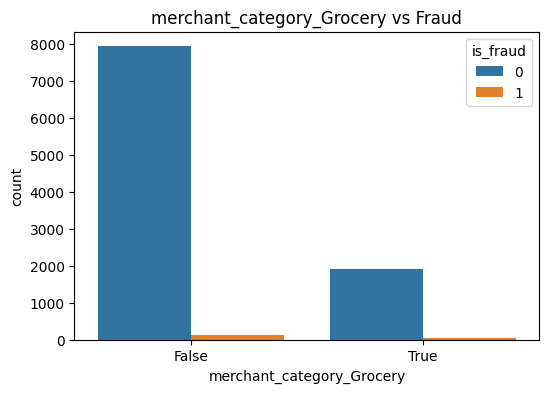

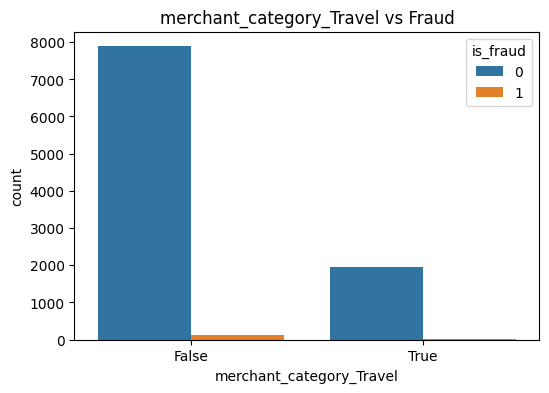

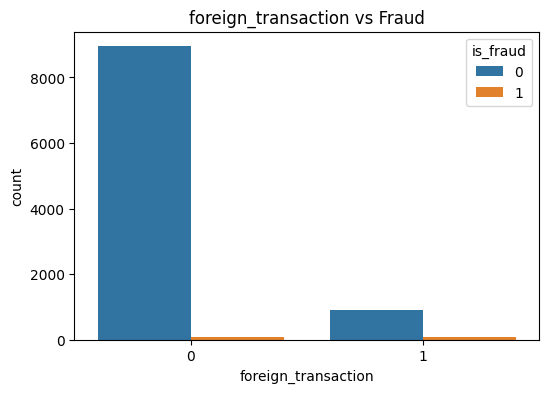

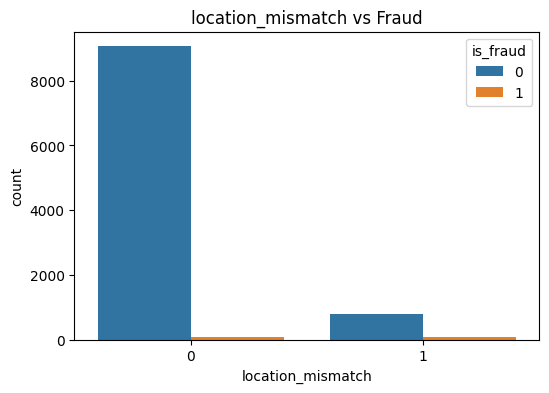

In [125]:
# =====================================
# HUBUNGAN FITUR KATEGORIKAL vs TARGET
# =====================================

categorical_features = ["merchant_category_Electronics","merchant_category_Food",
                        "merchant_category_Grocery", "merchant_category_Travel",
                        "foreign_transaction", "location_mismatch"]

for col in categorical_features:
    plt.figure(figsize=(6,4))
    sns.countplot(x=col, hue="is_fraud", data=df)
    plt.title(f"{col} vs Fraud")
    plt.show()

In [126]:
# =====================================
# PROPORSI FRAUD PER KATEGORI
# =====================================

for col in categorical_features:
    prop = pd.crosstab(df[col], df["is_fraud"], normalize='index')
    print(f"\nProporsi Fraud pada {col}:")
    print(prop)

# =====================================
# KORELASI DENGAN TARGET
# =====================================

corr_target = df.corr()["is_fraud"].sort_values(ascending=False)

print("\nKorelasi terhadap Fraud:")
print(corr_target)


Proporsi Fraud pada merchant_category_Electronics:
is_fraud                              0         1
merchant_category_Electronics                    
False                          0.984276  0.015724
True                           0.987520  0.012480

Proporsi Fraud pada merchant_category_Food:
is_fraud                       0         1
merchant_category_Food                    
False                   0.985329  0.014671
True                    0.983278  0.016722

Proporsi Fraud pada merchant_category_Grocery:
is_fraud                          0         1
merchant_category_Grocery                    
False                      0.986097  0.013903
True                       0.979938  0.020062

Proporsi Fraud pada merchant_category_Travel:
is_fraud                         0         1
merchant_category_Travel                    
False                     0.984769  0.015231
True                      0.985427  0.014573

Proporsi Fraud pada foreign_transaction:
is_fraud                    0 

DATA SPLITTING

In [127]:
# =====================================
# TRAIN TEST SPLIT
# =====================================

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

HYPERPARAMETER TUNING

In [128]:
#LOGISTIC REGRESSION
skf = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

pipe_log = Pipeline([
    ("smote", SMOTE(random_state=42)),
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(max_iter=1000))
])

param_log = {
    "model__C": [0.01, 0.1, 1, 10],
    "model__solver": ["lbfgs", "liblinear"]
}

log_random = RandomizedSearchCV(
    pipe_log,
    param_distributions=param_log,
    n_iter=6,
    cv=skf,
    n_jobs=-1,
    random_state=42
)

log_random.fit(X_train, y_train)

best_log_model1 = log_random.best_estimator_

In [129]:
#Tuning Random Forest
skf = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
pipe_rf = Pipeline([
    ("smote", SMOTE(random_state=42)),
    ("model", RandomForestClassifier(random_state=42))
])

param_rf = {
    "model__n_estimators": [100,200,300],
    "model__max_depth": [5,10,15],
    "model__min_samples_split": [2,5,10]
}

rf_random = RandomizedSearchCV(
    pipe_rf,
    param_distributions=param_rf,
    n_iter=10,
    cv=skf,
    n_jobs=-1,
    random_state=42
)

rf_random.fit(X_train, y_train)

best_rf_model1 = rf_random.best_estimator_

In [130]:
#Tuning XGBoost
skf = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
pipe_xgb = Pipeline([
    ("smote", SMOTE(random_state=42)),
    ("model", XGBClassifier(eval_metric="logloss", random_state=42))
])

param_xgb = {
    "model__n_estimators": [100,200,300],
    "model__max_depth": [4,6,8],
    "model__learning_rate": [0.01,0.05,0.1]
}

xgb_random = RandomizedSearchCV(
    pipe_xgb,
    param_distributions=param_xgb,
    n_iter=10,
    cv=skf,
    n_jobs=-1,
    random_state=42
)

xgb_random.fit(X_train, y_train)

best_xgb_model1 = xgb_random.best_estimator_

PEMBANGUNAN MODEL (MODEL BUILDING)

In [131]:
# =====================================
# Training model
# =====================================
log_model = log_random.best_estimator_
rf_model = rf_random.best_estimator_
xgb_model = xgb_random.best_estimator_

In [132]:
models = {
    "Logistic Regression": log_model,
    "Random Forest": rf_model,
    "XGBoost": xgb_model
}

models_eval = {
    "Logistic Regression": (log_model, X_test),
    "Random Forest": (rf_model, X_test),
    "XGBoost": (xgb_model, X_test)
}

ROC CURVE (grafik evaluasi performa model klasifikasi)

In [133]:
def plot_roc_curve(y_test, model, X_test, model_name, split):

    prob = model.predict_proba(X_test)[:,1]  # probabilitas kemungkinan transaksi fraud

    fpr, tpr, threshold = roc_curve(y_test, prob)  #Menghitung ROC Curve
    roc_auc = auc(fpr, tpr)         #Menghitung luas di bawah kurva

    plt.figure(figsize=(6,5))
    plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
    plt.plot([0,1],[0,1],'--')

    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(f"ROC Curve - {model_name} ({split})")

    plt.legend()
    plt.show()

THRESHOLD

In [134]:
def find_best_threshold(y_true, prob):
    #Menghitung nilai precision dan recall untuk berbagai kemungkinan ambang batas (threshold) dari hasil prediksi model.
    precision, recall, thresholds = precision_recall_curve(y_true, prob)

    # hitung F1-score untuk setiap threshold
    f1_scores = 2 * (precision * recall) / (precision + recall + 1e-9)

    # ambil threshold terbaik (F1 tertinggi)
    best_index = np.argmax(f1_scores)           #Mencari posisi (indeks) di mana nilai F1-Score-nya paling tinggi.
    best_threshold = thresholds[best_index]     #Mengambil nilai threshold yang menghasilkan F1-Score tertinggi tersebut.

    print("Best Threshold (berdasarkan F1):", best_threshold)
    print("Precision:", precision[best_index])
    print("Recall   :", recall[best_index])
    print("F1 Score :", f1_scores[best_index])

    return best_threshold

In [135]:
# =====================================
# MANUAL THRESHOLD (FOCUS: FRAUD SENSITIVITY)
# =====================================

thresholds = {
    "Logistic Regression": 0.3,
    "Random Forest": 0.25,
    "XGBoost": 0.2
}

print("\n==========================")
print("MANUAL THRESHOLD ACTIVE")
print("==========================")

for name, th in thresholds.items():
    print(f"{name}: {th}")


MANUAL THRESHOLD ACTIVE
Logistic Regression: 0.3
Random Forest: 0.25
XGBoost: 0.2


EVALUASI MODEL


EVALUASI MODEL (MANUAL THRESHOLD)

Model: Logistic Regression
Threshold (manual): 0.3
TN: 1773, FP: 197, FN: 1, TP: 29

--- Interpretasi Confusion Matrix ---
TN (True Negative)  : 1773 -> Prediksi benar NON-FRAUD (normal)
FP (False Positive) : 197 -> Normal tapi terdeteksi FRAUD (false alarm)
FN (False Negative) : 1 -> FRAUD tapi terdeteksi NORMAL (ini berbahaya)
TP (True Positive)  : 29 -> Prediksi benar FRAUD
Accuracy: 0.901
ROC AUC: 0.9810998307952623
Precision Fraud: 0.12831858407079647
Recall Fraud: 0.9666666666666667
F1 Fraud: 0.2265625


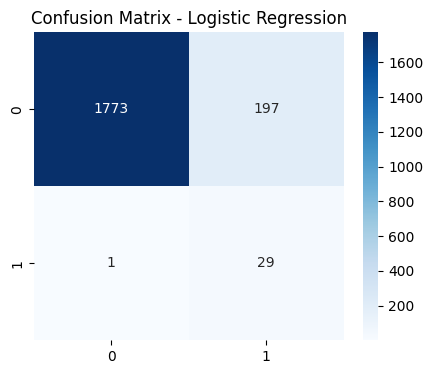

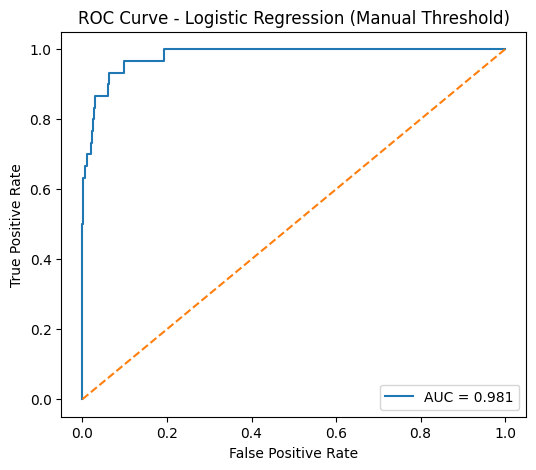


Model: Random Forest
Threshold (manual): 0.25
TN: 1903, FP: 67, FN: 1, TP: 29

--- Interpretasi Confusion Matrix ---
TN (True Negative)  : 1903 -> Prediksi benar NON-FRAUD (normal)
FP (False Positive) : 67 -> Normal tapi terdeteksi FRAUD (false alarm)
FN (False Negative) : 1 -> FRAUD tapi terdeteksi NORMAL (ini berbahaya)
TP (True Positive)  : 29 -> Prediksi benar FRAUD
Accuracy: 0.966
ROC AUC: 0.988984771573604
Precision Fraud: 0.3020833333333333
Recall Fraud: 0.9666666666666667
F1 Fraud: 0.4603174603174603


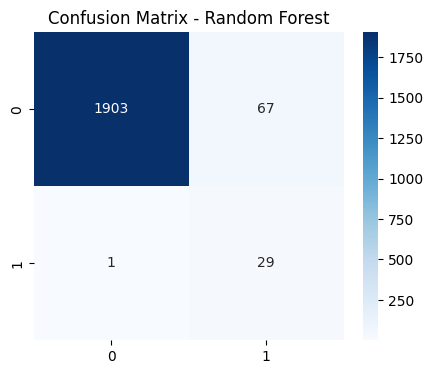

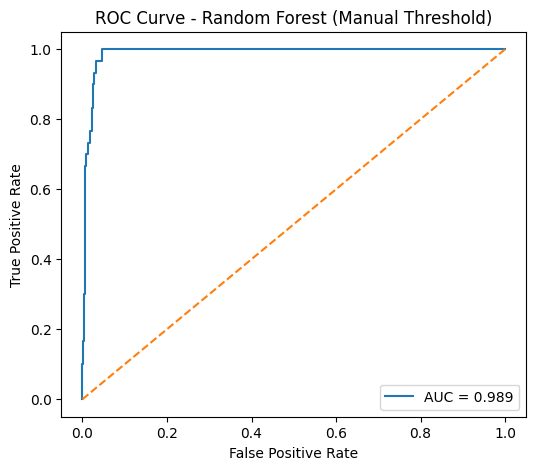


Model: XGBoost
Threshold (manual): 0.2
TN: 1931, FP: 39, FN: 2, TP: 28

--- Interpretasi Confusion Matrix ---
TN (True Negative)  : 1931 -> Prediksi benar NON-FRAUD (normal)
FP (False Positive) : 39 -> Normal tapi terdeteksi FRAUD (false alarm)
FN (False Negative) : 2 -> FRAUD tapi terdeteksi NORMAL (ini berbahaya)
TP (True Positive)  : 28 -> Prediksi benar FRAUD
Accuracy: 0.9795
ROC AUC: 0.994331641285956
Precision Fraud: 0.417910447761194
Recall Fraud: 0.9333333333333333
F1 Fraud: 0.5773195876288659


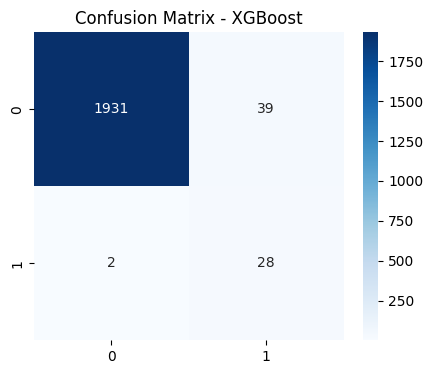

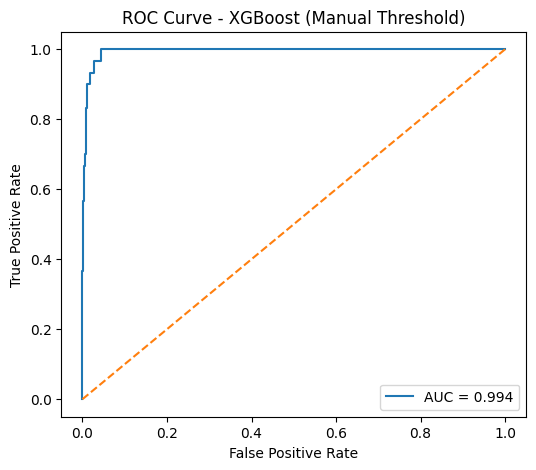

In [136]:
results = []

print("\n==========================")
print("EVALUASI MODEL (MANUAL THRESHOLD)")
print("==========================")

models = {
    "Logistic Regression": (log_model, X_test),
    "Random Forest": (rf_model, X_test),
    "XGBoost": (xgb_model, X_test)
}

for name, (model, Xtest) in models.items():

    # probabilitas
    proba = model.predict_proba(Xtest)[:, 1]

    # PAKAI MANUAL THRESHOLD
    threshold = thresholds[name]

    print(f"\nModel: {name}")
    print(f"Threshold (manual): {threshold}")

    # prediksi final
    pred = (proba >= threshold).astype(int)

    # evaluasi
    acc = accuracy_score(y_test, pred)
    roc = roc_auc_score(y_test, proba)

    report = classification_report(y_test, pred, output_dict=True)

    precision = report["1"]["precision"]
    recall = report["1"]["recall"]
    f1 = report["1"]["f1-score"]
    support = report["1"]["support"]

    cm = confusion_matrix(y_test, pred)
    tn, fp, fn, tp = cm.ravel()
    print(f"TN: {tn}, FP: {fp}, FN: {fn}, TP: {tp}")
    print("\n--- Interpretasi Confusion Matrix ---")
    print(f"TN (True Negative)  : {tn} -> Prediksi benar NON-FRAUD (normal)")
    print(f"FP (False Positive) : {fp} -> Normal tapi terdeteksi FRAUD (false alarm)")
    print(f"FN (False Negative) : {fn} -> FRAUD tapi terdeteksi NORMAL (ini berbahaya)")
    print(f"TP (True Positive)  : {tp} -> Prediksi benar FRAUD")

    print("Accuracy:", acc)
    print("ROC AUC:", roc)
    print("Precision Fraud:", precision)
    print("Recall Fraud:", recall)
    print("F1 Fraud:", f1)

    # print(f"TN: {tn}, FP: {fp}, FN: {fn}, TP: {tp}")

    # confusion matrix
    plt.figure(figsize=(5,4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
    plt.title(f"Confusion Matrix - {name}")
    plt.show()

    # ROC
    plot_roc_curve(y_test, model, Xtest, name, "Manual Threshold")

    results.append([
        "Manual Threshold",
        name,
        acc,
        roc,
        precision,
        recall,
        f1,
        support
    ])

MODEL COMPARISON

In [137]:
import pandas as pd

results_df = pd.DataFrame(results, columns=[
    "Setting", "Model", "Accuracy", "ROC AUC",
    "Precision", "Recall", "F1", "Support"
])

print("\n==========================")
print("MODEL COMPARISON")
print("==========================")

print(results_df)

# BEST MODEL (berdasarkan F1 Fraud)
best_model = results_df.sort_values(by="F1", ascending=False).iloc[0]

print("\n==========================")
print("BEST MODEL")
print("==========================")
print(best_model)


MODEL COMPARISON
            Setting                Model  Accuracy   ROC AUC  Precision  \
0  Manual Threshold  Logistic Regression    0.9010  0.981100   0.128319   
1  Manual Threshold        Random Forest    0.9660  0.988985   0.302083   
2  Manual Threshold              XGBoost    0.9795  0.994332   0.417910   

     Recall        F1  Support  
0  0.966667  0.226562     30.0  
1  0.966667  0.460317     30.0  
2  0.933333  0.577320     30.0  

BEST MODEL
Setting      Manual Threshold
Model                 XGBoost
Accuracy               0.9795
ROC AUC              0.994332
Precision             0.41791
Recall               0.933333
F1                    0.57732
Support                  30.0
Name: 2, dtype: object


DETEKSI OVERFITTING / UNDERFITTING

In [138]:
print("\n==========================")
print("OVERFITTING ANALYSIS")
print("==========================")

for name, (model, Xtest) in models.items():

    train_pred = model.predict(X_train)
    test_pred = model.predict(Xtest)

    train_acc = accuracy_score(y_train, train_pred)
    test_acc = accuracy_score(y_test, test_pred)

    gap = train_acc - test_acc

    print(f"\nModel: {name}")
    print(f"Train Acc: {train_acc:.4f}")
    print(f"Test Acc : {test_acc:.4f}")
    print(f"Gap      : {gap:.4f}")

    if gap > 0.1:
        print("⚠️ OVERFITTING")
    elif train_acc < 0.7:
        print("⚠️ UNDERFITTING")
    else:
        print("✅ STABLE MODEL")


OVERFITTING ANALYSIS

Model: Logistic Regression
Train Acc: 0.9337
Test Acc : 0.9360
Gap      : -0.0023
✅ STABLE MODEL

Model: Random Forest
Train Acc: 0.9961
Test Acc : 0.9830
Gap      : 0.0131
✅ STABLE MODEL

Model: XGBoost
Train Acc: 0.9999
Test Acc : 0.9865
Gap      : 0.0134
✅ STABLE MODEL


INFERENCE (SIMULASI DEPLOYMENT)

In [139]:
import joblib

# simpan model
joblib.dump(log_model, "log_model.pkl")
joblib.dump(rf_model, "rf_model.pkl")
joblib.dump(xgb_model, "xgb_model.pkl")
joblib.dump(thresholds, "thresholds.pkl")

['thresholds.pkl']

INFERENCE

In [140]:
# ==========================================
# REAL-TIME INFERENCE (INPUT USER)
# ==========================================

def input_transaction():
    print("\n=== INPUT TRANSAKSI ===")

    amount = float(input("Amount (Rp): "))
    transaction_hour = int(input("Jam transaksi (0-23): "))
    device_trust_score = float(input("Device trust score (0-1): "))
    velocity = int(input("Jumlah transaksi 24 jam terakhir: "))
    age = int(input("Umur pemegang kartu: "))

    foreign = int(input("Transaksi luar negeri? (1=Ya, 0=Tidak): "))
    mismatch = int(input("Lokasi tidak sesuai? (1=Ya, 0=Tidak): "))

    print("\nKategori Merchant:")
    print("1 = Electronics")
    print("2 = Food")
    print("3 = Grocery")
    print("4 = Travel")

    merchant_choice = int(input("Pilih kategori (1-4): "))

    # ======================================
    # BUILD INPUT DATA
    # ======================================
    data = {
        'amount_log': np.log1p(amount),
        'transaction_hour': transaction_hour,
        'device_trust_score': device_trust_score,
        'velocity_last_24h': velocity,
        'cardholder_age': age,
        'foreign_transaction': foreign,
        'location_mismatch': mismatch,
        'merchant_category_Electronics': 0,
        'merchant_category_Food': 0,
        'merchant_category_Grocery': 0,
        'merchant_category_Travel': 0
    }

    if merchant_choice == 1:
        data['merchant_category_Electronics'] = 1
    elif merchant_choice == 2:
        data['merchant_category_Food'] = 1
    elif merchant_choice == 3:
        data['merchant_category_Grocery'] = 1
    elif merchant_choice == 4:
        data['merchant_category_Travel'] = 1

    return data

# ==========================================
# LOOP REALTIME
# ==========================================

while True:

    user_input = input_transaction()

    print("\n==========================")
    print("HASIL ANALISIS")
    print("==========================")

    for model_name, model in models_dict.items():

        threshold = thresholds[model_name]

        status, prob = predict_fraud(model, user_input, threshold)
        risk = get_risk_level(prob, threshold)

        print(f"\nModel: {model_name}")
        print(f"Status      : {status}")
        print(f"Probability : {prob:.4f}")
        print(f"Threshold   : {threshold}")
        print(f"Risk Level  : {risk}")

    lanjut = input("\nCoba lagi? (y/n): ")
    if lanjut.lower() != 'y':
        print("Selesai.")
        break


=== INPUT TRANSAKSI ===
Amount (Rp): 30000
Jam transaksi (0-23): 7
Device trust score (0-1): 0.45
Jumlah transaksi 24 jam terakhir: 1
Umur pemegang kartu: 34
Transaksi luar negeri? (1=Ya, 0=Tidak): 0
Lokasi tidak sesuai? (1=Ya, 0=Tidak): 0

Kategori Merchant:
1 = Electronics
2 = Food
3 = Grocery
4 = Travel
Pilih kategori (1-4): 2

HASIL ANALISIS

Model: Logistic Regression
Status      : FRAUD
Probability : 0.9749
Threshold   : 0.3
Risk Level  : HIGH RISK

Model: Random Forest
Status      : NORMAL
Probability : 0.0183
Threshold   : 0.25
Risk Level  : LOW RISK

Model: XGBoost
Status      : NORMAL
Probability : 0.0012
Threshold   : 0.2
Risk Level  : LOW RISK

Coba lagi? (y/n): n
Selesai.
